## Random Forest

In [125]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')

In [126]:
# Load Data
df = pd.read_csv("../data/processed/model_ready.csv")

In [127]:
# Define target and feature columns
target = 'final_four'
features = [
    'barthag',
    'adj_o',
    'adj_d',
    'adj_t',
    'seed_filled',
    'elite_seed',
    'wab',
    'ov_cur_sos'
]

X = df[features]
y = df[target]

print(f"Number of features: {len(features)}")
print(f"Number of samples: {len(df)}")
print(f"\nFeature columns: {features[:10]}")

Number of features: 8
Number of samples: 5607

Feature columns: ['barthag', 'adj_o', 'adj_d', 'adj_t', 'seed_filled', 'elite_seed', 'wab', 'ov_cur_sos']


In [128]:
# Time-based split - Train on 2008-2021, Test on 2022-2024
train_mask = df['year'] <= 2021
test_mask = df['year'] >= 2022

X_train = df[train_mask][features]
X_test = df[test_mask][features]
y_train = df[train_mask][target]
y_test = df[test_mask][target]

print("="*50)
print("TIME-BASED TRAIN-TEST SPLIT")
print("="*50)
print(f"\nTraining years: {sorted(df[train_mask]['year'].unique())}")
print(f"Test years: {sorted(df[test_mask]['year'].unique())}")
print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set Final Four teams: {y_train.sum()}")
print(f"Test set Final Four teams: {y_test.sum()}")

TIME-BASED TRAIN-TEST SPLIT

Training years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]
Test years: [2022, 2023, 2024]

Training set size: 4524
Test set size: 1083

Training set Final Four teams: 52
Test set Final Four teams: 12


### SMOTE

* Use for high class imbalance (Final Four Teams vs. Non-Final Four Teams)

Class distribution after SMOTE:
final_four
0    4472
1     894
Name: count, dtype: int64
SMOTE RESAMPLING

Class distribution BEFORE SMOTE:
final_four
0    4472
1      52
Name: count, dtype: int64

Class distribution AFTER SMOTE:
final_four
0    4472
1     894
Name: count, dtype: int64

Original training set size: 4524
Resampled training set size: 5366


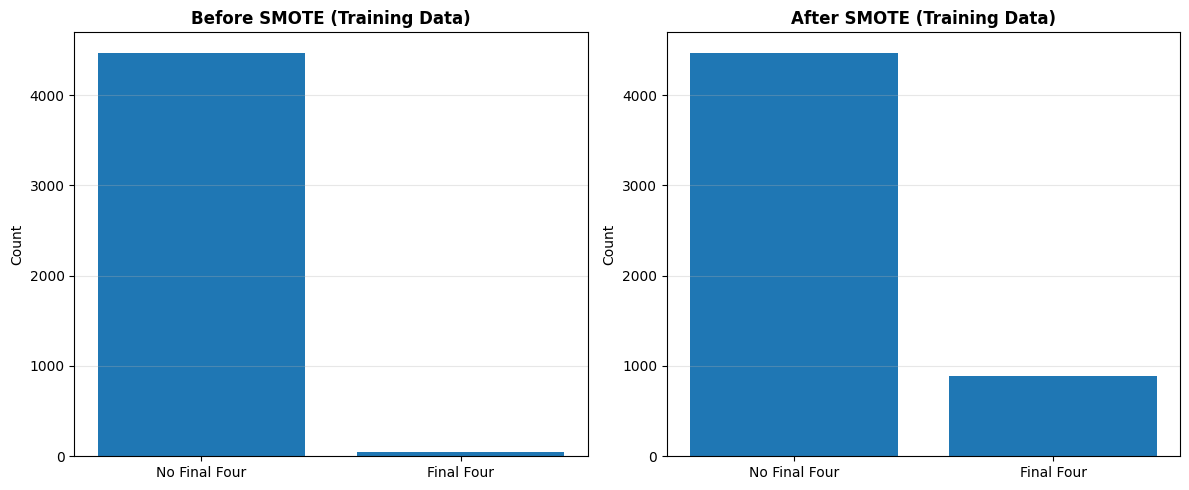

In [129]:
# Use SMOTE but don't balance to 50-50
smote = SMOTE(random_state=42, sampling_strategy=0.2)  # 20% ratio instead of 1.0 (50-50)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("="*50)
print("SMOTE RESAMPLING")
print("="*50)
print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nOriginal training set size: {len(X_train)}")
print(f"Resampled training set size: {len(X_train_resampled)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Final Four', 'Final Four'], y_train.value_counts().sort_index())
axes[0].set_title('Before SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(['No Final Four', 'Final Four'], 
            pd.Series(y_train_resampled).value_counts().sort_index())
axes[1].set_title('After SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Training

In [130]:
# Train Random Forest with good default parameters
rf_model = RandomForestClassifier(
    n_estimators=250,           # Good balance of performance/speed
    max_depth=15,               # Allow deeper trees with your data size
    min_samples_split=20,       # More conservative splitting
    min_samples_leaf=10,        # Prevent tiny leaf nodes
    max_features='sqrt',        # Standard for classification
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=15, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=250, n_jobs=-1, random_state=42)

In [131]:
# Make predictions on test set (2022-2024)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("="*50)
print("PREDICTIONS ON TEST SET (2022-2024)")
print("="*50)
print(f"Predicted Final Four teams: {y_pred.sum()}")
print(f"Actual Final Four teams: {y_test.sum()}")
print(f"Prediction rate: {y_pred.sum() / len(y_pred):.2%}")
print(f"Actual rate: {y_test.sum() / len(y_test):.2%}")

PREDICTIONS ON TEST SET (2022-2024)
Predicted Final Four teams: 25
Actual Final Four teams: 12
Prediction rate: 2.31%
Actual rate: 1.11%


CONFUSION MATRIX
[[1053   18]
 [   5    7]]


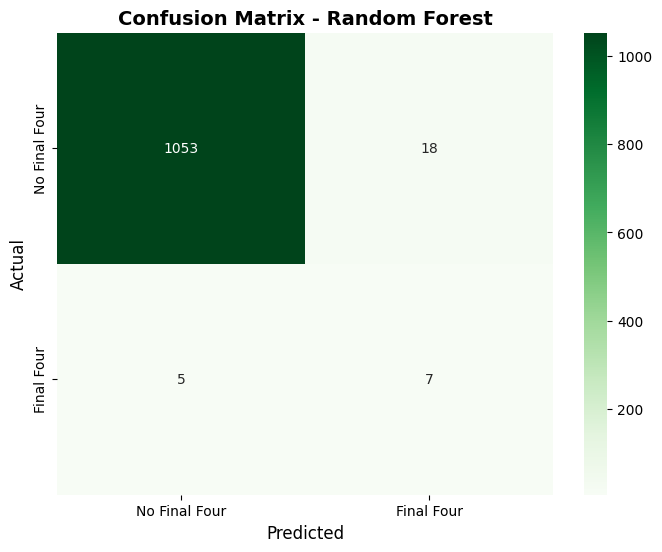

In [132]:
# Confusion Matrix
print("="*50)
print("CONFUSION MATRIX")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [133]:
# Classification Report
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1071
           1       0.28      0.58      0.38        12

    accuracy                           0.98      1083
   macro avg       0.64      0.78      0.68      1083
weighted avg       0.99      0.98      0.98      1083



### ROC-AUC Score

* Score is high because most teams are not Final-Four caliber

ROC-AUC Score: 0.9628


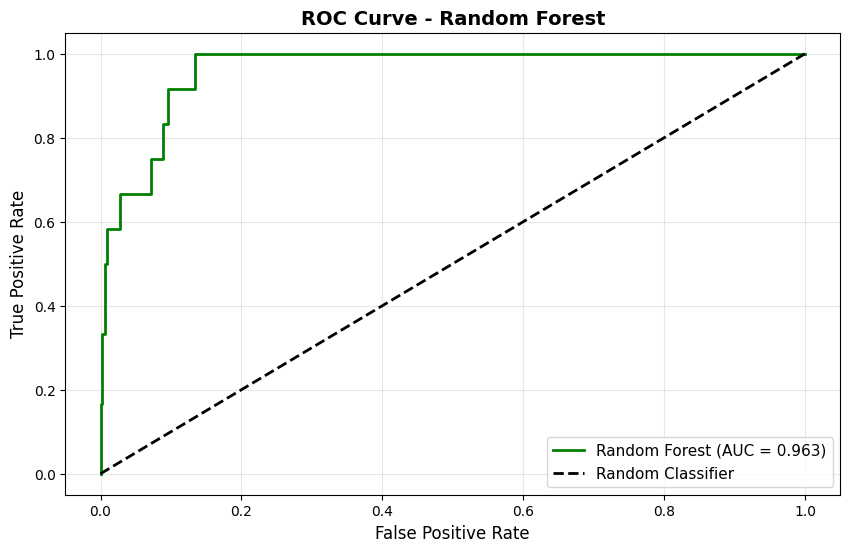

In [134]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Random Forest (AUC = {roc_auc:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Threshold Analysis

THRESHOLD ANALYSIS


,Threshold,Predicted,True Pos,False Pos,False Neg,Precision,Recall,F1-Score
0,0.30,36,7,29,5,0.194444,0.583333,0.291667
1,0.40,31,7,24,5,0.225806,0.583333,0.325581
2,0.50,25,7,18,5,0.280000,0.583333,0.378378
3,0.60,15,6,9,6,0.400000,0.500000,0.444444
4,0.70,5,3,2,9,0.600000,0.250000,0.352941
5,0.80,3,2,1,10,0.666667,0.166667,0.266667
6,0.90,2,1,1,11,0.500000,0.083333,0.142857
7,0.95,1,0,1,12,0.000000,0.000000,0.000000


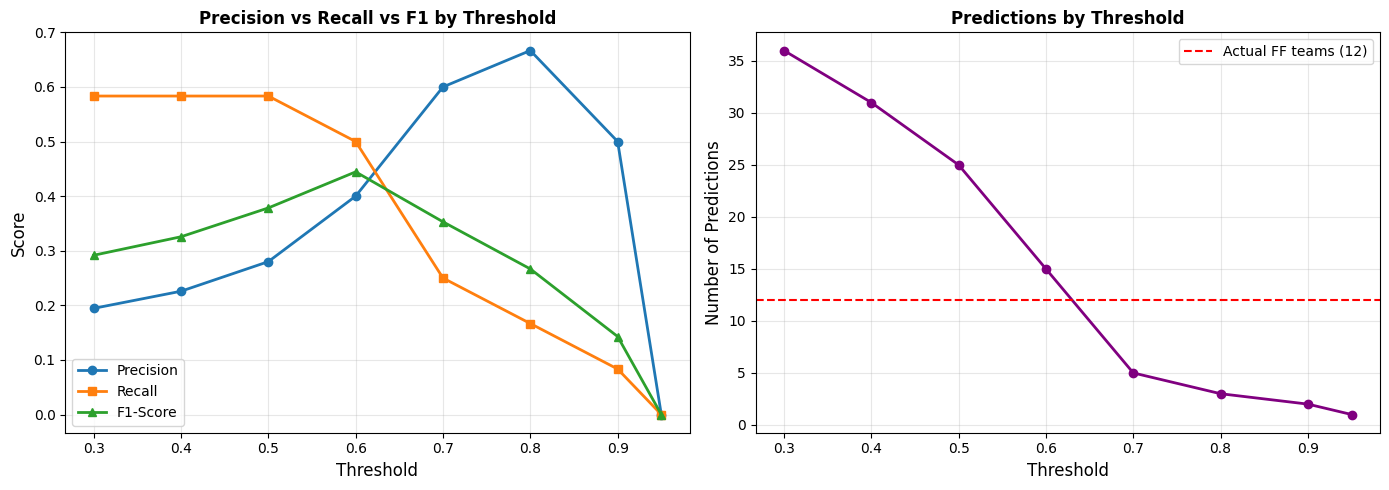

In [135]:
# Test different thresholds to find the sweet spot
print("="*50)
print("THRESHOLD ANALYSIS")
print("="*50)

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
results_list = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    
    tn, fp, fn, tp = cm_thresh.ravel()
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    results_list.append({
        'Threshold': thresh,
        'Predicted': y_pred_thresh.sum(),
        'True Pos': tp,
        'False Pos': fp,
        'False Neg': fn,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

threshold_df = pd.DataFrame(results_list)
display(threshold_df)

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision vs Recall
axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'], 'o-', label='Precision', linewidth=2)
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'], 's-', label='Recall', linewidth=2)
axes[0].plot(threshold_df['Threshold'], threshold_df['F1-Score'], '^-', label='F1-Score', linewidth=2)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision vs Recall vs F1 by Threshold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of predictions
axes[1].plot(threshold_df['Threshold'], threshold_df['Predicted'], 'o-', linewidth=2, color='purple')
axes[1].axhline(y=12, color='red', linestyle='--', label='Actual FF teams (12)')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Number of Predictions', fontsize=12)
axes[1].set_title('Predictions by Threshold', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RESULTS WITH OPTIMAL THRESHOLD = 0.5

Confusion Matrix:
[[1053   18]
 [   5    7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1071
           1       0.28      0.58      0.38        12

    accuracy                           0.98      1083
   macro avg       0.64      0.78      0.68      1083
weighted avg       0.99      0.98      0.98      1083



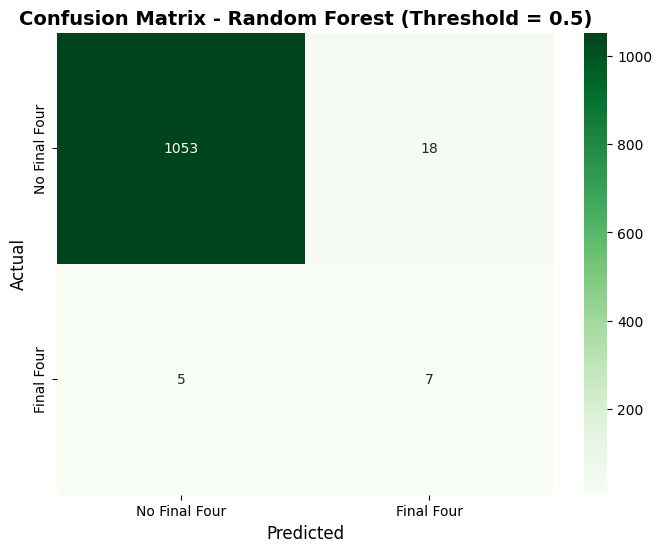

In [136]:
# Choose optimal threshold based on the analysis above
optimal_threshold = 0.5

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print("="*50)
print(f"RESULTS WITH OPTIMAL THRESHOLD = {optimal_threshold}")
print("="*50)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print("\nConfusion Matrix:")
print(cm_optimal)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'])
plt.title(f'Confusion Matrix - Random Forest (Threshold = {optimal_threshold})', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

### Feature Importance

In [137]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*50)
print("FEATURE IMPORTANCE")
print("="*50)
display(feature_importance)

# Summary statistics
print(f"\nTotal features: {len(feature_importance)}")

FEATURE IMPORTANCE


,feature,importance
0,barthag,0.269444
6,wab,0.174109
4,seed_filled,0.160674
1,adj_o,0.117459
5,elite_seed,0.102723
2,adj_d,0.089815
7,ov_cur_sos,0.044732
3,adj_t,0.041043



Total features: 8


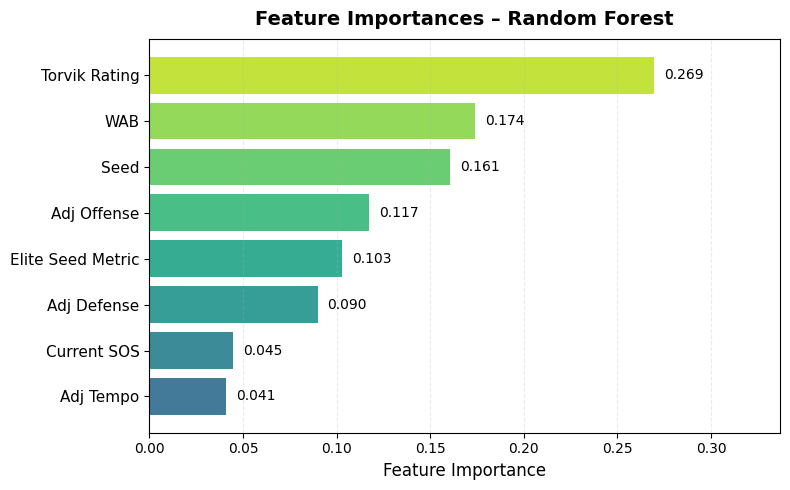

In [144]:
label_map = {
    "barthag": "Torvik Rating",
    "seed_filled": "Seed",
    "adj_t": "Adj Tempo",
    "adj_d": "Adj Defense",
    "adj_o": "Adj Offense",
    "elite_seed": "Elite Seed Metric",
    "ov_cur_sos": "Current SOS",
    "wab": "WAB"
}
df['clean_label'] = df['feature'].map(label_map).fillna(df['feature'])

plt.figure(figsize=(8, 5))
ax = plt.gca()

y_pos = np.arange(len(df))
colors = plt.cm.viridis(np.linspace(0.35, 0.9, len(df)))
bars = ax.barh(y_pos, df['importance'], color=colors, alpha=0.9)

max_val = df['importance'].max()
ax.set_xlim(0, max_val * 1.25)

ax.set_yticks(y_pos)
ax.set_yticklabels(df['clean_label'], fontsize=11)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importances – Random Forest', fontsize=14, fontweight='bold', pad=10)

ax.grid(axis='x', linestyle='--', alpha=0.25)

for bar, val in zip(bars, df['importance']):
    ax.text(
        val + max_val * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()